In [30]:
import os
import uuid
from __future__ import annotations
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field

from dotenv import load_dotenv
from langchain_core.language_models import BaseChatModel
from langchain_core.messages import (
    SystemMessage,
    AIMessage,
    HumanMessage,
    RemoveMessage,
    BaseMessage
)
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from google.genai.errors import ClientError

from chatbot import logger
from chatbot.utils.common import read_yaml
from chatbot.constants import CONFIG_FILE_PATH
from chatbot.tools import ALL_TOOLS

In [31]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str

In [32]:
configuration = read_yaml(CONFIG_FILE_PATH)
load_dotenv()

[2026-06-11 15:55:07,826]:INFO:common.py:Yaml file: /home/jatin/Projects/chatbot/config/settings.yaml is loaded successfully


True

In [33]:
def get_llm() -> BaseChatModel:
    provider = configuration.llm.provider
    model = configuration.llm.model
    temperature = configuration.llm.temperature
    max_tokens = configuration.llm.max_tokens
    api_key = os.getenv('LLM_API_KEY')

    if provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(
            model=model,
            temperature=temperature,
            max_tokens=max_tokens,
            api_key=api_key,
        )

    elif provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(
            model=model,
            temperature=temperature,
            max_tokens=max_tokens,
            api_key=api_key,
        )

    elif provider == "groq":
        from langchain_groq import ChatGroq
        return ChatGroq(
            model=model,
            temperature=temperature,
            max_tokens=max_tokens,
            api_key=api_key,
        )
    elif provider == 'google_gemini':
        from langchain_google_genai import ChatGoogleGenerativeAI
        return ChatGoogleGenerativeAI(
            model=model,
            temperature=temperature,
            max_tokens=max_tokens,
            api_key=api_key,
        )
    else:
        raise ValueError(
            f"Unknown LLM_PROVIDER: '{provider}'. "
            "Choose from: 'anthropic', 'openai', 'groq', 'google_gemini'"
        )

In [34]:
############### Helper Methods ###########


def fetch_ltm_memory(
        config: RunnableConfig,
        store: BaseStore
):
    response = {
        "status":False,
        "data":""
    }
    try:
        # Get User Id and Create Name Space
        user_id = config.get("configurable", {}).get('user_id')
        if not user_id:
            logger.warning("Skipping LTM extraction: user_id not found.")
            return response
        namespace = ("user", user_id, "details")

        # Fetch all memory under namespace
        try:
            ltm_memory = store.search(namespace)
        except Exception as e:
            logger.exception(
                f"Failed to fetch memories for namespace={namespace}",
            )
            return response
        
        # Take all the memory in single sentence
        existing_memory = "(empty)"
        if ltm_memory:
            memories = []
            for memory in ltm_memory:
                try:
                    if (
                        memory
                        and getattr(memory, "value", None)
                        and memory.value.get("data")
                    ):
                        memories.append(memory.value["data"])
                except Exception:
                    logger.warning(
                        "Skipping malformed memory item: %s",
                        memory,
                        exc_info=True,
                    )
            if memories:
                existing_memory = "\n".join(memories)
        if existing_memory:
            response.update({
                "status":True,
                "data":"existing_memory",
                })
        return response
    except Exception as e:
        logger.exception(
            f"Unexpected error in extract_ltm_info: {e}"
        )
        return response
    

############## Helper Methods for Conditional routing ######################


def should_summarize(state: AgentState):
    try:
        no_of_messages_kept = configuration.stm.messages_kept
    except Exception as e:
        logger.error(f"Invalid configuration for 'messages_kept': {e}")
    return len(state["messages"]) > ( no_of_messages_kept or 20 )


def _route_after_llm(state: AgentState) -> str:
    """
    Combined router after llm_call:
    - If LLM made tool calls → go to tools
    - Else if summarization needed → go to summarize
    - Else → end
    """
    last_message = state["messages"][-1]

    # Check for tool calls first
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    
    # Check if summarization is needed
    if should_summarize(state):
        return "summarize"
    
    return END

In [35]:
def preprocess(state: AgentState) -> dict:
    messages = state["messages"]
    if not messages or not isinstance(messages[0], SystemMessage):
        system_msg = SystemMessage(content=configuration.system_prompt)
        messages = [system_msg] + list(messages)
    return {"messages": messages}

In [36]:
def summarize_conversation(state: AgentState) -> dict:
    """
    Node 1 — Summarize Conversation
    ---------------------------------
    - Summarize the conversation 
    - Remove messages other than last N messages mentioned in configuraion.
    """

    existing_summary = state["summary"] or ""
    new_conversation = state["messages"]

    try:
        prompt = configuration.prompts.summary_prompt
        prompt = prompt.format(
            existing_summary=HumanMessage(content=existing_summary),
            new_conversation=new_conversation
        )
    except KeyError as e:
        logger.exception(
            f"Prompt template is missing a required key, "
            f"therefore skipping summarization"
        )
        return {}
    except Exception as e:
        logger.exception(
            f"Unexpected error while formatting summary prompt, "
            f"therefore skipping summarization"
        )
        return {}

    try:
        llm = get_llm(configuration)
    except Exception as e:
        logger.exception(
            f"Failed to initialize LLM — skipping memory summarization"
        )
        return {}
    
    try:
        response = llm.invoke(prompt)
    except Exception as e:
        logger.exception(f"LLM invocation failed during summarization: {e}")
        return {}

    if not getattr(response, "content", None):
        logger.warning("LLM returned an empty or invalid response — skipping summarization.")
        return {}
    try:
    # Keep last N messages
        no_of_messages_kept = configuration.stm.messages_kept 
        messages_to_delete = state["messages"][:-no_of_messages_kept]
        return {
            "summary": response.content,
            "messages": [RemoveMessage(id=message.id) for message in messages_to_delete],
        }
    except (AttributeError, TypeError) as e:
        logger.error(f"Invalid configuration for 'messages_kept': {e}")
        return {}
    except Exception as e:
        logger.exception(f"Unexpected error while preparing state update: {e}")
        return {}

In [ ]:
def extract_ltm_info(
        state: AgentState,
        config: RunnableConfig,
        store: BaseStore
):
    """
    Node 2 — Extract Long Term Memory
    -----------------
    Extract Info for Long Term Memory from 
    Conversation between user and Chatbot.
    """
    try:
        res = fetch_ltm_memory(configuration, store)
        if res.get('status'):
            existing_memory = res.get('data')
            user_id = config.get("configurable", {}).get('user_id')
            namespace = ("user", user_id, "details")
        else:
            return {}

        # latest user message
        messages = state.get("messages", [])
        if not messages:
            logger.warning(
                "Skipping LTM extraction: no messages found."
            )
            return {}

        last_message = messages[-1]
        if not getattr(last_message, "content", None):
            logger.warning(
                "Skipping LTM extraction: last message has no content."
            )
            return {}

        last_text = str(last_message.content)


        # Initialize the LLM with structured output
        try:
            llm = get_llm(configuration)
            memory_llm = llm.with_structured_output(MemoryDecision)
        except Exception as e:
            logger.exception(
                f"Failed to initialize memory extraction LLM: {e}"
            )
            return {}
        
        # Get Memory Prompt
        try:
            memory_prompt = configuration.prompts.memory_prompt
        except Exception:
            logger.exception(
                "Memory prompt not found in config."
            )
            return {}

        # Invoke the LLM
        try:
            decision: MemoryDecision = memory_llm.invoke(
                [
                    SystemMessage(
                        content=memory_prompt.format(
                            user_details_content=existing_memory
                        )
                    ),
                    {
                        "role": "user", 
                        "content": last_text
                    },
                ]
            )
        except Exception as e:
            logger.exception(
                f"Memory extraction LLM invocation failed: {e}"
            )
            return {}
        # Store the memories
        if decision.should_write:
            
            for memory in decision.memories:
                if memory.is_new and memory.text.strip():
                    store.put(namespace, str(uuid.uuid4()), {"data": memory.text.strip()})
        return {}
    except Exception as e:
        logger.exception(
            f"Unexpected error in extract_ltm_info: {e}"
        )
        return {}

In [ ]:
def llm_call(
        state: AgentState,
        config: RunnableConfig,
        store: BaseStore
) -> dict:
    """
    Node 2 — LLM Call
    -----------------
    Sends the full message history to the configured LLM 
    and appends the reply.
    """
    res = fetch_ltm_memory(config, store)
    if res.get('status'):
        existing_memory = res.get('data')
    else:
        existing_memory = "(empty)"
    
    system_prompt = configuration.prompts.system_prompt
    system_prompt.format(
        user_details_content=existing_memory
    )

    # STM Summarization Implementation Start
    messages = []
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        }) 
    messages.extend(state["messages"])
    llm_messages = [
        SystemMessage(content=system_prompt),
        *messages
    ]
    # STM Summarization Implementation End

    try:
        llm = get_llm(configuration)
        if configuration.features.tools_enabled:
            llm = llm.bind_tools(ALL_TOOLS)
        response: AIMessage = llm.invoke(llm_messages)
        return {"messages": [response]}
    except ValueError as e:
        # Missing API key or unknown provider — config issue

        logger.error(f"LLM configuration error in llm_call: {e}")
        return {
            "messages": [
                AIMessage(content=
                    "⚠️ LLM configuration error. "
                    "Check your API key and provider settings."
                )
            ]
        }
    except ClientError as e:
        logger.exception(f"LLM usage error in occured")
        if 'RESOURCE_EXHAUSTED' in str(e) or '429' in str(e):
            user_msg = (
                    "⚠️ I've hit my free usage limit for today. "
                    "Please try again later."
                )
        else:
            user_msg = "❌ An API error occurred. Please try again."
        return {
            "messages": [
                AIMessage(content=user_msg)
            ]
        }
    except ImportError as e:
        # Provider package not installed

        logger.error(f"LLM package missing in llm_call: {e}")
        return {
            "messages": [
                AIMessage(content=
                    "⚠️ A required LLM package is missing. "
                    "Checchatbot_with_langgraphk logs for the install command."
                )
            ]
        }
    except Exception as e:
        # Network error, auth failure, rate limit, etc.
        logger.exception(f"Unexpected error during LLM invocation: {e}")
        return {
            "messages": [
                AIMessage(content=
                    "⚠️ Something went wrong while contacting the LLM. "
                    "Check logs for details."
                )
            ]
        }

In [39]:
builder = StateGraph(AgentState)

In [40]:
builder.add_node("preprocess", preprocess)
builder.add_node("ltm_info", extract_ltm_info)
builder.add_node("llm_call", llm_call)
builder.add_node("summarize_conversation", summarize_conversation)
if configuration.features.tools_enabled:
    builder.add_node("tools", ToolNode(ALL_TOOLS))

In [41]:
builder.add_edge(START, "preprocess")
builder.add_edge('preprocess', "ltm_info")
builder.add_edge("ltm_info", "llm_call")
if configuration.features.tools_enabled:
    builder.add_conditional_edges(
                    "llm_call",
                    _route_after_llm, 
                    {
                        "tools": "tools",
                        "summarize": "summarize_conversation",    
                        END:END
                    }
                )
    builder.add_edge("tools", "llm_call")
else:
    builder.add_conditional_edges(
                    "llm_call",
                    should_summarize,
                    {
                        True: "summarize_conversation",
                        False: END,
                    }
                )
builder.add_edge("summarize_conversation", END)

In [42]:
workflow = builder.compile()

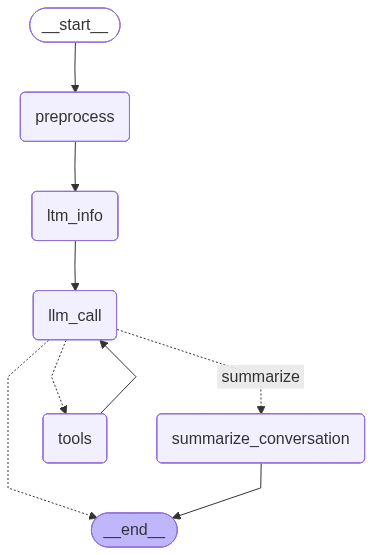

In [43]:
workflow